In [42]:
import matplotlib.pyplot as plt
from sympy.physics.control.control_plots import matplotlib

# 定义标签和中文名称映射关系
classification_names = {
    0: '上衣',
    1: '鞋',
    2: '包',
    3: '下装',
    4: '手表'
}

In [43]:
import torch
import torchvision.transforms as T
from PIL import Image
import os
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import re

In [44]:
def sorted_alphanum(img_names):
    convert = lambda str: int(str) if str.isdigit() else str.lower()
    alphanum_key = lambda name: [convert(x) for x in re.split(r'([0-9]+)', name)]
    return sorted(img_names, key=alphanum_key)

## 自定义数据集类

In [45]:
class ImageLabelDataset(Dataset):
    # 初始化
    def __init__(self, image_dir, label_path, transform=None):
        self.image_dir = image_dir
        self.label_path = label_path
        self.transform = transform
        self.image_names = sorted_alphanum(os.listdir(image_dir))
        label_data = pd.read_csv(self.label_path)
        self.labels = label_data['target'].tolist()
    # 获取数据集长度
    def __len__(self):
        return len(self.image_names)
    # 根据索引获取元素：(input, target) = (image, label)
    def __getitem__(self, idx):
        # 1. 构建图片的完整访问路径
        image_path = os.path.join(self.image_dir, self.image_names[idx])
        # 2. 打开图片
        image = Image.open(image_path).convert('RGB')
        # 3. 应用转换操作，得到Tensor
        if self.transform is not None:
            img_tensor = self.transform(image)
        else:
            raise ValueError("transform 参数不能为 None！")
        # 4. 找到图片对应的分类标签
        img_label = self.labels[idx]

        return img_tensor, img_label

## 创建和划分数据集

In [46]:
# 定义图像转换操作（调整大小，转为Tensor）
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
])

# 创建数据集
dataset = ImageLabelDataset(image_dir='../common/dataset', label_path='../common/fashion-labels.csv', transform=transform)
print(len(dataset))

24853


In [47]:
print(dataset[0])  # 输出第一个样本的图像张量和标签

(tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]]), 3)


In [48]:
print(dataset.image_names)

['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '66.jpg', '67.jpg', '68.jpg', '69.jpg', '70.jpg', '71.jpg', '72.jpg', '73.jpg', '74.jpg', '75.jpg', '76.jpg', '77.jpg', '78.jpg', '79.jpg', '80.jpg', '81.jpg', '82.jpg', '83.jpg', '84.jpg', '85.jpg', '86.jpg', '87.jpg', '88.jpg', '89.jpg', '90.jpg', '91.jpg', '92.jpg', '93.jpg', '94.jpg', '95.jpg', '96.jpg', '97.jpg', '98.jpg', '99.jpg', '100.jpg'

In [49]:
print(dataset.labels)

[3, 3, 3, 0, 3, 0, 0, 0, 3, 0, 3, 0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 0, 0, 0, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 0, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 3, 3, 0, 0, 0, 0, 

In [50]:
# 划分数据集
train_dateset, test_dataset = random_split(dataset, [0.75, 0.25])
print(len(train_dateset))
print(len(test_dataset))

18640
6213


In [51]:
batch_size = 32
# 创建数据加载器
train_loader = DataLoader(train_dateset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [52]:
for input, target in train_loader:
    print(f"input shape: {input.shape}, target shape: {target.shape}")
    break

input shape: torch.Size([32, 3, 64, 64]), target shape: torch.Size([32])


In [53]:
data_iter = iter(test_loader)
input, target = next(data_iter)
print(f"input shape: {input.shape}, target shape: {target.shape}")

input shape: torch.Size([32, 3, 64, 64]), target shape: torch.Size([32])


## 定义模型

In [54]:
import torch.nn as nn


In [55]:
class Classifier(nn.Module):
    # 初始化，传入分类数
    def __init__(self, n_classes=5):
        super(Classifier, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1), # 输出特征形状不变
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # 输出特征形状减半

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1), # 输出特征形状不变
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

            nn.Flatten(), # 将多维特征图展平为一维向量

            nn.Linear(in_features=16*16*16, out_features=n_classes) # 输出n_classes个类别的得分
        )

    # 前向传播
    def forward(self, x):
        return self.model(x)


In [56]:
model = Classifier(n_classes=5)

In [57]:
print(input.shape)

torch.Size([32, 3, 64, 64])


In [58]:
output = model(input)
print(output.shape)

torch.Size([32, 5])


In [63]:
print(output)

tensor([[ 0.0866, -0.1716, -0.0197,  0.0386, -0.0298],
        [ 0.0851, -0.1782,  0.0424,  0.0539, -0.0231],
        [ 0.0983, -0.1298,  0.0312,  0.0317, -0.0380],
        [ 0.0560, -0.1600,  0.0117,  0.0325, -0.0817],
        [ 0.0868, -0.1475,  0.0096,  0.0504, -0.0448],
        [ 0.0831, -0.1915,  0.0206,  0.0310, -0.0227],
        [ 0.0779, -0.2046,  0.0266,  0.0427, -0.0510],
        [ 0.0984, -0.1771,  0.0050,  0.0308, -0.0402],
        [ 0.0635, -0.1577,  0.0684,  0.0654, -0.0439],
        [ 0.0840, -0.1731,  0.0270,  0.0419, -0.0393],
        [ 0.0697, -0.1727,  0.0132,  0.0354, -0.0577],
        [ 0.0940, -0.1750,  0.0378,  0.0426, -0.0222],
        [ 0.0820, -0.1587,  0.0432,  0.0400, -0.0442],
        [ 0.0935, -0.1966,  0.0459,  0.0270, -0.0164],
        [ 0.0769, -0.2016,  0.0225,  0.0266, -0.0421],
        [ 0.0930, -0.1802,  0.0469,  0.0416, -0.0299],
        [ 0.0716, -0.1755,  0.0702,  0.0536, -0.0063],
        [ 0.0967, -0.1708,  0.0176,  0.0274, -0.0374],
        [ 

## 模型训练

In [65]:
# 超参数
lr = 1e-3
epochs = 10

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Classifier(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=5, bias=True)
  )
)

In [66]:
# 损失函数
loss_fn = nn.CrossEntropyLoss()

# 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [67]:
# 训练流程
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for input, target in train_loader:
        input = input.to(device)
        target = target.to(device)

        # 前向传播
        output = model(input)
        # 计算损失
        loss = loss_fn(output, target)
        # 反向传播，计算梯度
        loss.backward()
        # 更新参数
        optimizer.step()
        # 梯度清零
        optimizer.zero_grad()
        # 累加损失
        train_loss += loss.item()
    # 计算本轮次平均损失
    this_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {this_loss:.4f}")

Epoch [1/10], Loss: 0.2016
Epoch [2/10], Loss: 0.0709
Epoch [3/10], Loss: 0.0538
Epoch [4/10], Loss: 0.0434
Epoch [5/10], Loss: 0.0372
Epoch [6/10], Loss: 0.0301
Epoch [7/10], Loss: 0.0279
Epoch [8/10], Loss: 0.0220
Epoch [9/10], Loss: 0.0182
Epoch [10/10], Loss: 0.0160


## 测试

In [80]:
import matplotlib.pyplot as plt

In [74]:
# 模拟输入新图片，进行预测
data_iter = iter(test_loader)
# 1. 获取一批数据
images, labels = next(data_iter)

In [75]:
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [76]:
# 2. 前向传播，得到预测结果
with torch.no_grad():
    inputs = images.to(device)
    outputs = model(inputs)
print(outputs.shape)

torch.Size([32, 5])


In [77]:
# 3. 得到预测分类标签
pred_labels = outputs.argmax(dim=1).cpu().numpy()
print(pred_labels.shape)

(32,)


In [78]:
# 4. 转换输入图片，为画图做准备
images = images.permute(0, 2, 3, 1).numpy()  # 转换为 (batch_size, height, width, channels)
print(images.shape)

(32, 64, 64, 3)


1-label: 4
1-pred: 4, 分类: 手表

2-label: 1
2-pred: 1, 分类: 鞋

3-label: 0
3-pred: 0, 分类: 上衣

4-label: 2
4-pred: 2, 分类: 包

5-label: 0
5-pred: 0, 分类: 上衣

6-label: 0
6-pred: 0, 分类: 上衣

7-label: 0
7-pred: 0, 分类: 上衣

8-label: 4
8-pred: 4, 分类: 手表

9-label: 3
9-pred: 3, 分类: 下装

10-label: 2
10-pred: 2, 分类: 包



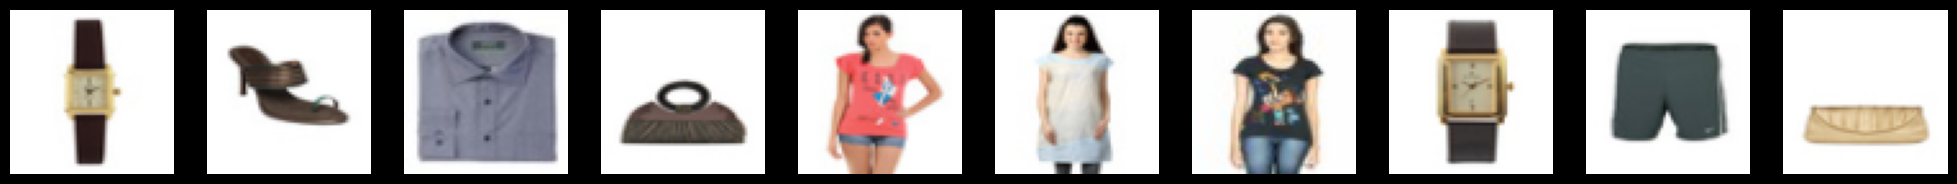

In [81]:
# 对比显示预测结果
fig, axes = plt.subplots(1, 10, figsize=(25, 4), sharex=True, sharey=True)
for i in range(10):
    axes[i].imshow(images[i])
    axes[i].axis('off')
    # 真实标签
    print(f"{i+1}-label: {labels[i]}")
    # 预测标签
    pred_class = classification_names[pred_labels[i]]
    print(f"{i+1}-pred: {pred_labels[i]}, 分类: {pred_class}")
    print()
plt.show()

In [82]:
# 计算测试集准确率
test_acc_num = 0
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        # 前向传播
        outputs = model(inputs)
        # 得到预测分类标签
        pred_labels = outputs.argmax(dim=1)
        # 累加预测准确的个数
        test_acc_num += pred_labels.eq(targets).sum().item()

# 计算准确率
test_acc = test_acc_num / len(test_dataset)
print(f"测试集准确率: {test_acc:.4f}")

测试集准确率: 0.9860
